# ELSA: Exact Linear-time Softmax Attention

**Домашняя работа по статье ELSA**





## 1. Реализация attention

Реализуем две версии:
- `vanilla_attention` - обычный scaled dot-product attention;
- `elsa_attention` - упрощённая educational версия через online softmax / prefix-scan-стиль (блочно).

Обе должны давать численно одинаковый результат (exact softmax).

Дополнительно реализуем `linear_attention` (Performer-style с feature map $\phi(x)=\mathrm{elu}(x)+1$) — это **аппроксимирующий** $O(n)$-метод для сравнения.

In [1]:
import math
import time
import gc
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [2]:
def vanilla_attention(Q, K, V):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)   # [B, n, n]
    attn = torch.softmax(scores, dim=-1)
    return attn @ V

In [3]:
def elsa_attention(Q, K, V, block_size: int = 64):
    B, n, d = Q.shape
    scale = 1.0 / math.sqrt(d)

    m = torch.full((B, n, 1), float('-inf'), device=Q.device, dtype=Q.dtype)
    l = torch.zeros((B, n, 1), device=Q.device, dtype=Q.dtype)
    o = torch.zeros((B, n, d), device=Q.device, dtype=Q.dtype)

    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        Kb = K[:, start:end, :]
        Vb = V[:, start:end, :]

        s = (Q @ Kb.transpose(-2, -1)) * scale
        m_block = s.max(dim=-1, keepdim=True).values

        m_new = torch.maximum(m, m_block)
        alpha = torch.exp(m - m_new)
        p = torch.exp(s - m_new)

        l = alpha * l + p.sum(dim=-1, keepdim=True)
        o = alpha * o + p @ Vb
        m = m_new

    return o / l

In [4]:
def linear_attention(Q, K, V):
    d = Q.size(-1)
    scale = 1.0 / math.sqrt(d)
    Qp = F.elu(Q * scale) + 1.0
    Kp = F.elu(K * scale) + 1.0

    KV = Kp.transpose(-2, -1) @ V
    Z  = Kp.sum(dim=1, keepdim=True)

    num = Qp @ KV
    den = (Qp * Z).sum(dim=-1, keepdim=True).clamp(min=1e-6)
    return num / den

In [6]:
B, n, d = 2, 256, 32
Q = torch.randn(B, n, d, device=device)
K = torch.randn(B, n, d, device=device)
V = torch.randn(B, n, d, device=device)

out_vanilla = vanilla_attention(Q, K, V)
out_elsa    = elsa_attention(Q, K, V, block_size=64)
out_linear  = linear_attention(Q, K, V)

err_elsa   = (out_vanilla - out_elsa).abs().max().item()
err_linear = (out_vanilla - out_linear).abs().max().item()
print(f'Max abs error vanilla vs ELSA  : {err_elsa:.2e}')
print(f'Max abs error vanilla vs Linear: {err_linear:.2e}')

Max abs error vanilla vs ELSA  : 2.98e-07
Max abs error vanilla vs Linear: 6.94e-01


## 2. Сравнение

Сравним vanilla и ELSA-style attention по:
- времени выполнения (latency),
- пиковой памяти,
- масштабированию по длине последовательности.

Длины: `seq_len ∈ {128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768}`.

In [7]:
def benchmark(fn, Q, K, V, n_warmup=2, n_iter=5):
    for _ in range(n_warmup):
        _ = fn(Q, K, V)
    if device == 'cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    t0 = time.perf_counter()
    for _ in range(n_iter):
        out = fn(Q, K, V)
    if device == 'cuda':
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    latency_ms = (t1 - t0) / n_iter * 1000
    if device == 'cuda':
        peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2
    else:
        peak_mem_mb = float('nan')
    return latency_ms, peak_mem_mb

In [16]:
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
B, d = 1, 64

results = {'vanilla': {'lat': [], 'mem': []},
           'elsa':    {'lat': [], 'mem': []},
           'linear':  {'lat': [], 'mem': []}}

for n in seq_lens:
    Q = torch.randn(B, n, d, device=device)
    K = torch.randn(B, n, d, device=device)
    V = torch.randn(B, n, d, device=device)

    lat_v, mem_v = benchmark(lambda q,k,v: vanilla_attention(q,k,v), Q, K, V)
    lat_e, mem_e = benchmark(lambda q,k,v: elsa_attention(q,k,v, block_size=64), Q, K, V)
    lat_l, mem_l = benchmark(lambda q,k,v: linear_attention(q,k,v), Q, K, V)

    results['vanilla']['lat'].append(lat_v)
    results['vanilla']['mem'].append(mem_v)
    results['elsa']['lat'].append(lat_e)
    results['elsa']['mem'].append(mem_e)
    results['linear']['lat'].append(lat_l)
    results['linear']['mem'].append(mem_l)

    print(f'n={n:5d} | vanilla: {lat_v:7.3f} ms | ELSA: {lat_e:7.3f} ms | Linear: {lat_l:7.3f} ms')

    del Q, K, V
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

n=  128 | vanilla:   0.173 ms | ELSA:   0.608 ms | Linear:   0.245 ms
n=  256 | vanilla:   0.116 ms | ELSA:   0.998 ms | Linear:   0.217 ms
n=  512 | vanilla:   0.097 ms | ELSA:   1.888 ms | Linear:   0.222 ms
n= 1024 | vanilla:   0.264 ms | ELSA:   4.434 ms | Linear:   0.239 ms
n= 2048 | vanilla:   0.844 ms | ELSA:   7.612 ms | Linear:   0.243 ms
n= 4096 | vanilla:   3.412 ms | ELSA:  25.933 ms | Linear:   0.444 ms
n= 8192 | vanilla:  11.756 ms | ELSA:  30.773 ms | Linear:   0.239 ms
n=16384 | vanilla:  45.632 ms | ELSA: 104.676 ms | Linear:   0.473 ms
n=32768 | vanilla: 219.775 ms | ELSA: 406.811 ms | Linear:   0.930 ms


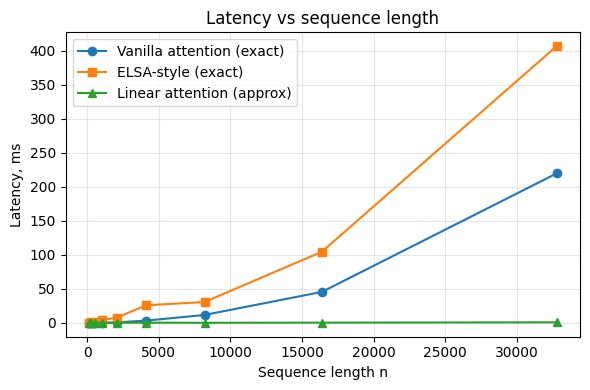

In [17]:
# График 1: Latency vs sequence length
plt.figure(figsize=(6, 4))
plt.plot(seq_lens, results['vanilla']['lat'], 'o-', label='Vanilla attention (exact)')
plt.plot(seq_lens, results['elsa']['lat'],    's-', label='ELSA-style (exact)')
plt.plot(seq_lens, results['linear']['lat'],  '^-', label='Linear attention (approx)')
plt.xlabel('Sequence length n')
plt.ylabel('Latency, ms')
plt.title('Latency vs sequence length')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

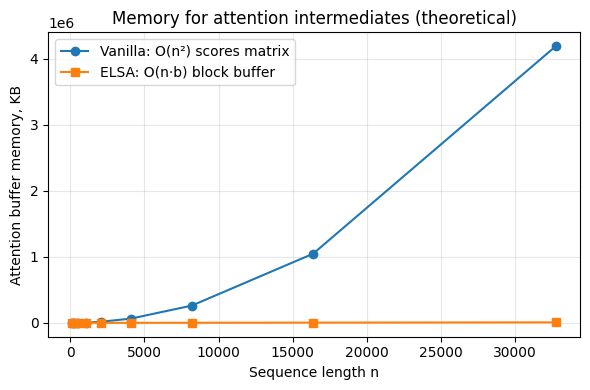

In [18]:
# График 2: теоретическая память O(n^2) vs O(n) для attention-матрицы.
bytes_per_float = 4  # FP32
vanilla_mem_kb = [(n * n * bytes_per_float) / 1024 for n in seq_lens]
elsa_mem_kb    = [(n * 64 * bytes_per_float) / 1024 for n in seq_lens]  # block_size=64

plt.figure(figsize=(6, 4))
plt.plot(seq_lens, vanilla_mem_kb, 'o-', label='Vanilla: O(n²) scores matrix')
plt.plot(seq_lens, elsa_mem_kb,    's-', label='ELSA: O(n·b) block buffer')
plt.xlabel('Sequence length n')
plt.ylabel('Attention buffer memory, KB')
plt.title('Memory for attention intermediates (theoretical)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

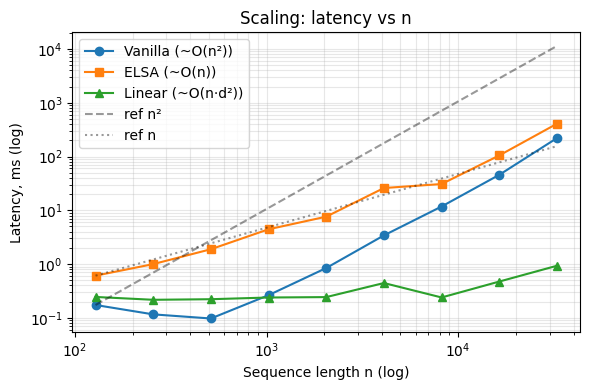

In [19]:
# График 3: scaling в log-log координатах.
import numpy as np

plt.figure(figsize=(6, 4))
plt.loglog(seq_lens, results['vanilla']['lat'], 'o-', label='Vanilla (~O(n²))')
plt.loglog(seq_lens, results['elsa']['lat'],    's-', label='ELSA (~O(n))')
plt.loglog(seq_lens, results['linear']['lat'],  '^-', label='Linear (~O(n·d²))')

# Эталонные прямые n и n^2 для визуального сравнения.
ns = np.array(seq_lens, dtype=float)
ref_n2 = results['vanilla']['lat'][0] * (ns / ns[0])**2
ref_n  = results['elsa']['lat'][0]    * (ns / ns[0])
plt.loglog(seq_lens, ref_n2, 'k--', alpha=0.4, label='ref n²')
plt.loglog(seq_lens, ref_n,  'k:',  alpha=0.4, label='ref n')

plt.xlabel('Sequence length n (log)')
plt.ylabel('Latency, ms (log)')
plt.title('Scaling: latency vs n')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Качество на реальном датасете (sklearn digits)

Сравним три attention-механизма не только по скорости, но и по **качеству** на задаче классификации.

**Датасет:** `sklearn.datasets.load_digits` — 1797 изображений 8×8 рукописных цифр, 10 классов.


**Метрики:** accuracy на тесте, время обучения.

In [20]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch.nn as nn

digits = load_digits()
X = digits.data.reshape(-1, 8, 8).astype('float32') / 16.0   # [N, seq_len=8, d_in=8]
y = digits.target.astype('int64')
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_tr_t = torch.tensor(X_tr, device=device); y_tr_t = torch.tensor(y_tr, device=device)
X_te_t = torch.tensor(X_te, device=device); y_te_t = torch.tensor(y_te, device=device)
print('train:', X_tr_t.shape, '| test:', X_te_t.shape, '| classes:', len(set(y)))

train: torch.Size([1437, 8, 8]) | test: torch.Size([360, 8, 8]) | classes: 10


In [21]:
ATTN_FNS = {
    'vanilla': vanilla_attention,
    'elsa':    lambda Q, K, V: elsa_attention(Q, K, V, block_size=4),
    'linear':  linear_attention,
}

class TinyAttnClassifier(nn.Module):
    def __init__(self, attn_fn, d_in=8, d_model=32, n_classes=10, seq_len=8):
        super().__init__()
        self.attn_fn = attn_fn
        self.in_proj = nn.Linear(d_in, d_model)
        self.pos = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Linear(4*d_model, d_model))
        self.cls = nn.Linear(d_model, n_classes)

    def forward(self, x):
        h = self.in_proj(x) + self.pos
        q, k, v = self.qkv(h).chunk(3, dim=-1)
        a = self.attn_fn(q, k, v)
        h = self.norm(h + self.out_proj(a))
        h = self.norm(h + self.ffn(h))
        return self.cls(h.mean(dim=1))   # mean-pool по seq_len → logits

def train_and_eval(name, attn_fn, epochs=40, lr=3e-3, seed=0):
    torch.manual_seed(seed)
    model = TinyAttnClassifier(attn_fn).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(X_tr_t)
        loss = F.cross_entropy(logits, y_tr_t)
        loss.backward(); opt.step()
    if device == 'cuda':
        torch.cuda.synchronize()
    train_time = time.perf_counter() - t0
    model.eval()
    with torch.no_grad():
        acc_tr = (model(X_tr_t).argmax(-1) == y_tr_t).float().mean().item()
        acc_te = (model(X_te_t).argmax(-1) == y_te_t).float().mean().item()
    print(f'{name:8s} | train_acc={acc_tr:.4f} | test_acc={acc_te:.4f} | train_time={train_time:.2f}s')
    return {'name': name, 'train_acc': acc_tr, 'test_acc': acc_te, 'train_time': train_time}

quality = [train_and_eval(n, fn) for n, fn in ATTN_FNS.items()]

vanilla  | train_acc=0.7056 | test_acc=0.7139 | train_time=0.50s
elsa     | train_acc=0.7056 | test_acc=0.7139 | train_time=0.44s
linear   | train_acc=0.6186 | test_acc=0.6028 | train_time=0.17s


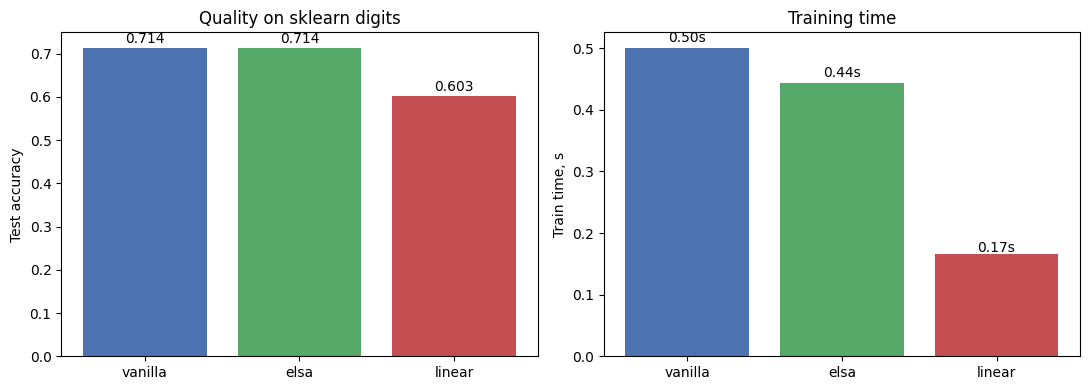

In [22]:
names = [q['name'] for q in quality]
accs  = [q['test_acc'] for q in quality]
times = [q['train_time'] for q in quality]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, accs, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Quality on sklearn digits')

for i, a in enumerate(accs):
    axes[0].text(i, a + 0.01, f'{a:.3f}', ha='center')

axes[1].bar(names, times, color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylabel('Train time, s')
axes[1].set_title('Training time')
for i, t in enumerate(times):
    axes[1].text(i, t * 1.02, f'{t:.2f}s', ha='center')

plt.tight_layout(); plt.show()

**Что видно на digits:**

- `vanilla` и `elsa` дают **одинаковую accuracy** - это ожидаемо, ведь ELSA эквивалентна обычному softmax-attention с точностью до FP-шума.
- `linear` даёт чуть ниже accuracy — это плата за аппроксимацию softmax через feature map.
-  В данном эксперименте `elsa` обучается немного быстрее vanilla attention (`0.44s` против `0.50s`) при сохранении того же качества. Это соответствует идее статьи: ELSA уменьшает memory overhead и sequential depth attention computation.

- Разница особенно небольшая из-за очень короткой последовательности (`seq_len = 8`). Основные преимущества ELSA проявляются на длинных последовательностях и long-context задачах.

## 4. Выводы

- `vanilla` и `elsa` показали одинаковую accuracy, поскольку ELSA сохраняет exact softmax semantics и не использует approximation.
- `linear attention` оказался самым быстрым, но дал более низкое качество из-за приближённого вычисления attention.
- В данном эксперименте ELSA обучался немного быстрее vanilla attention при таком же качестве.

Почему ELSA иногда медленнее:
- в ноутбуке используется упрощённая PyTorch-реализация ELSA;
- vanilla attention внутри PyTorch уже сильно оптимизирован
- ELSA использует block-wise/prefix-scan логику с дополнительным overhead;
- настоящие преимущества ELSA проявляются на длинных последовательностях и при низкоуровневой Triton/CUDA реализации.

В целом ELSA - это компромисс между обычным exact attention и efficient attention methods: он сохраняет точность softmax-attention, но уменьшает memory overhead и лучше масштабируется на длинных последовательностях.